In [1]:
%pip install xgboost

   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
    --------------------------------------- 1.6/101.7 MB 8.6 MB/s eta 0:00:12
   -- ------------------------------------- 5.2/101.7 MB 15.5 MB/s eta 0:00:07
   --- ------------------------------------ 8.4/101.7 MB 14.1 MB/s eta 0:00:07
   ---- ----------------------------------- 11.0/101.7 MB 13.7 MB/s eta 0:00:07
   ----- ---------------------------------- 13.9/101.7 MB 13.5 MB/s eta 0:00:07
   ------ --------------------------------- 17.3/101.7 MB 13.9 MB/s eta 0:00:07
   -------- ------------------------------- 21.2/101.7 MB 14.5 MB/s eta 0:00:06
   --------- ------------------------------ 24.1/101.7 MB 14.5 MB/s eta 0:00:06
   ---------- ----------------------------- 25.7/101.7 MB 13.8 MB/s eta 0:00:06
   ---------- ----------------------------- 27.0/101.7 MB 13.0 MB/s eta 0:00:06
   ----------- ---------------------------- 28.3/101.7 MB 12.4 MB/s eta 0:00:06
   ----------- ---------------------------- 29.1/101.


[notice] A new release of pip is available: 25.2 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score


# Classification

In [3]:
data = load_breast_cancer(as_frame=True)
X = data["data"]
y = data["target"]
features = data["feature_names"]

In [4]:
# For reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

In [5]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=RANDOM_STATE, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=RANDOM_STATE, stratify=y_train)

print(f"Training set size: {X_train.shape[0]}")
print(f"Validation set size: {X_val.shape[0]}")
print(f"Test set size: {X_test.shape[0]}")

Training set size: 318
Validation set size: 80
Test set size: 171


## Train and evaluate RF (for comparison)

In [6]:
rf_clf = RandomForestClassifier(n_estimators=10000,
                              max_features='sqrt',
                              random_state=RANDOM_STATE,
                              oob_score=True, # enable OOB calculation
                              n_jobs=-1)

rf_clf.fit(X_train, y_train)

y_pred_train_rf = rf_clf.predict(X_train)
y_pred_val_rf = rf_clf.predict(X_val)

acc_train_rf = accuracy_score(y_train, y_pred_train_rf)
acc_val_rf = accuracy_score(y_val, y_pred_val_rf)

print(f"RF Training Accuracy:\t{acc_train_rf:.4f}")
print(f"RF Validation Accuracy:\t{acc_val_rf:.4f}")
print(f"RF OOB Accuracy:\t{rf_clf.oob_score_}")

RF Training Accuracy:	1.0000
RF Validation Accuracy:	0.9625
RF OOB Accuracy:	0.9591194968553459


### Short digression: Visualizing partitioning in multidimensional spaces

In [7]:
# Really important for what is to come!
sc = StandardScaler()
X_train_scaled = sc.fit_transform(X_train)
X_val_scaled = sc.transform(X_val)

In [8]:
# TODO: Use PCA to reduce dimensionality for plotting.
pca = PCA(n_components=2)
X_train_scaled_pca = pca.fit_transform(X_train)
X_val_scaled_pca = pca.transform(X_val)

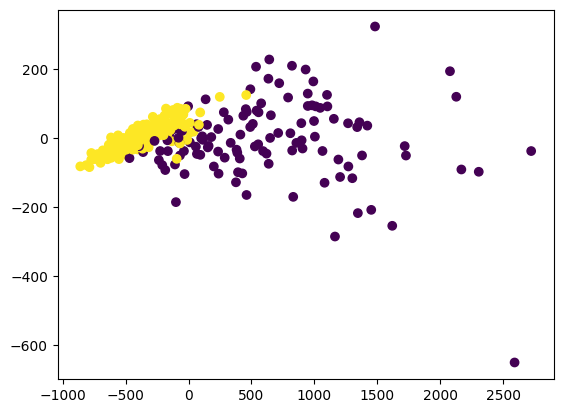

In [9]:
plt.scatter(X_train_scaled_pca[:,0],X_train_scaled_pca[:,1], c=y_train)

In [10]:
# Repetition: plot decision boundaries.
def plot_soft_decision_boundaries_rf(X, y, model, padding_x=0.1, padding_y=0.1):
    h = 0.05

    # Set the boundaries of the mesh grid
    x_min, x_max = X[:, 0].min() - padding_x, X[:, 0].max() + padding_x
    y_min, y_max = X[:, 1].min() - padding_y, X[:, 1].max() + padding_y
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))

    # Predict class probabilities for each point in the grid
    grid = np.c_[xx.ravel(), yy.ravel()]
    probs = model.predict_proba(grid)
    Z = 1- probs[:,0]  # Max class probability at each point
    Z = Z.reshape(xx.shape)

    # Plot soft decision boundary as probability contours
    plt.figure(figsize=(8, 6))
    contour = plt.contourf(xx, yy, Z, alpha=0.8, cmap=plt.cm.coolwarm)
    scatter = plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k', cmap=plt.cm.coolwarm)
    plt.colorbar(label='Class 0 probability')
    plt.xlabel(data["feature_names"][0])
    plt.ylabel(data["feature_names"][1])
    plt.title("Random Forest Soft Decision Boundaries")
    plt.show()


In [1]:
# TODO: Play around with complexity. How does this change the visualization?
rf_tmp = RandomForestClassifier(n_estimators=100,
                              max_features='sqrt',
                              random_state=RANDOM_STATE,
                              max_depth=None,
                              oob_score=True, # enable OOB calculation
                              n_jobs=-1)
rf_tmp.fit(X_train_scaled_pca, y_train)

y_pred_train_tmp = rf_tmp.predict(X_train_scaled_pca)
y_pred_val_tmp = rf_tmp.predict(X_val_scaled_pca)

acc_train_tmp = accuracy_score(y_train, y_pred_train_tmp)
acc_val_tmp = accuracy_score(y_val, y_pred_val_tmp)

print(f"RF Training Accuracy: {acc_train_tmp:.4f}")
print(f"RF Validation Accuracy: {acc_val_tmp:.4f}")


plot_soft_decision_boundaries_rf(X_train_scaled_pca, y_train, rf_tmp)

NameError: name 'RandomForestClassifier' is not defined

## Gradient Boosting (Gradient Boosted Trees)

New criterion: Friedman MSE.
- Normal MSE is prone to creating highly unbalanced splits (mean squared error in all children)
- Friedman looks at both sides in detail:
  - Let $n_L$ and $n_R$ be the number of samples in the left and right nodes.
  - Let $S_L$ and $S_R$ be the sum of the residuals in the left and right nodes.
  - Then: $$ \text{Improvement} \approx \frac{n_L n_R}{n_L + n_R} \left( \frac{S_L}{n_L} - \frac{S_R}{n_R} \right)^2 $$

Unbalanced splits have their weight minimal (e.g., 1000 samples are split 1 vs. 999)
$$ \frac{1 * 999}{1 + 999} = \frac{999}{1000} \approx 1 $$

However, balanced splits are rewarded.
$$ \frac{500 * 500}{500 + 500} = \frac{250000}{1000} = 250 $$

This actively rewards choosing balanced splits, and penalizes the algorithm for chasing outliers!

In [11]:
# TODO: Parameterize GBT
gbt_clf = GradientBoostingClassifier(
    n_estimators=100)

gbt_clf.fit(X_train, y_train)

y_pred_train_gbt = gbt_clf.predict(X_train)
acc_train_gbt = accuracy_score(y_train, y_pred_train_gbt)

y_pred_val_gbt = gbt_clf.predict(X_val)
acc_val_gbt = accuracy_score(y_val, y_pred_val_gbt)


print(f"GBT Train Accuracy: {acc_train_gbt:.4f}")
print(f"GBT Validation Accuracy: {acc_val_gbt:.4f}")

GBT Train Accuracy: 1.0000
GBT Validation Accuracy: 0.9750


### XGBoost

XGBoost offers an optimized way to train gradient boosted ensembles. Most people use this implementation instead of scikit-learn.

In [12]:
from xgboost import XGBClassifier
# https://xgboost.readthedocs.io/en/release_3.0.0/parameter.html

# TODO: Parameterize XGB.
xgb_clf = XGBClassifier(
    n_estimators=100
)
xgb_clf.fit(X_train, y_train)

acc_train_xgbc = accuracy_score(y_train, xgb_clf.predict(X_train))
acc_val_xgbc = accuracy_score(y_val, xgb_clf.predict(X_val))

print(f"XGB Train Accuracy {acc_train_xgbc:.4f}")
print(f"XGB Validation Accuracy: {acc_val_xgbc:.4f}")

XGB Train Accuracy 1.0000
XGB Validation Accuracy: 0.9875


### Model Selection & Evaluation

In [13]:
print(f"RF\tValidation Accuracy {acc_val_rf:.4f}")
print(f"GBT\tValidation Accuracy: {acc_val_gbt:.4f}")
print(f"XGB\tValidation Accuracy: {acc_val_xgbc:.4f}")

RF	Validation Accuracy 0.9625
GBT	Validation Accuracy: 0.9750
XGB	Validation Accuracy: 0.9875


In [14]:
accuracy_score(y_test, gbt_clf.predict(X_test))

0.9590643274853801

### Demonstration: Speed difference on large(r) datasets.

In [19]:
from sklearn.datasets import fetch_covtype

cov_data = fetch_covtype()
X_cov = cov_data["data"]
y_cov = cov_data["target"]

print(cov_data["DESCR"])

# y-1 because classes given are 1-7, but need 0-6
X_cov_train, X_cov_val, y_cov_train, y_cov_val = train_test_split(X_cov, y_cov-1, test_size=0.3, random_state=42, stratify=y_cov)

.. _covtype_dataset:

Forest covertypes
-----------------

The samples in this dataset correspond to 30×30m patches of forest in the US,
collected for the task of predicting each patch's cover type,
i.e. the dominant species of tree.
There are seven covertypes, making this a multiclass classification problem.
Each sample has 54 features, described on the
`dataset's homepage <https://archive.ics.uci.edu/ml/datasets/Covertype>`__.
Some of the features are boolean indicators,
while others are discrete or continuous measurements.

**Data Set Characteristics:**

=================   ============
Classes                        7
Samples total             581012
Dimensionality                54
Features                     int
=================   ============

:func:`sklearn.datasets.fetch_covtype` will load the covertype dataset;
it returns a dictionary-like 'Bunch' object
with the feature matrix in the ``data`` member
and the target values in ``target``. If optional argument 'as_frame' is
se

In [20]:
# This takes ~11min on CPU on my machine for n_estimators=100. 
# Therefore limited to n_estimators=10 here.
gbt_clf = GradientBoostingClassifier(
    n_estimators=10,
    max_depth=3,
    random_state=RANDOM_STATE
)
gbt_clf.fit(X_cov_train, y_cov_train)

y_pred_val_gbt = gbt_clf.predict(X_cov_val)
acc_val_gbt = accuracy_score(y_cov_val, y_pred_val_gbt)

print(f"GBT Val Accuracy: {acc_val_gbt:.4f}")

GBT Val Accuracy: 0.7106


In [22]:
from xgboost import XGBClassifier
xgb_clf = XGBClassifier(
    n_estimators=1000,
    max_depth=3,
    device="gpu",
    random_state=RANDOM_STATE
)
xgb_clf.fit(X_cov_train, y_cov_train)

y_pred_val_xgbc = xgb_clf.predict(X_cov_val)
acc_val_xgbc = accuracy_score(y_cov_val, y_pred_val_xgbc)

print(f"XGB Validation Accuracy: {acc_val_xgbc:.4f}")

c:\Users\arsan\AppData\Local\Programs\Python\Python314\Lib\site-packages\xgboost\core.py:751: UserWarning: [11:31:10] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\common\error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)


XGB Validation Accuracy: 0.8761


How exactly is it so fast? After all it is pure sequential, isn't it?
- Better optimization algorithm (More information about the loss landscape allows the algorithm to converge in fewer iterations)
  - GBT: First order derivative (Gradient)
  - XGB: Taylor expansion (Gradient + hessian)
- Parallel and Efficient Split Finding
  - To find splits, we need to sort data! XGB sorts ALL columns once before training.
  - Multiple blocks/columns can be scanned for good splits simultaneously.
  - Instead of trying every split, statistics are used (percentiles/quantiles) to pick from several "candidates" only
- Cache & Compression to read data faster (and handle big datasets better without crashing!)

# Regression

In [23]:
import numpy as np
import pandas as pd
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score


housing = fetch_california_housing(as_frame=True)

X = housing.data
y = housing.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42)

print(f"\nTraining set size: {X_train.shape[0]} samples")
print(f"Validation set size: {X_val.shape[0]} samples")
print(f"Test set size: {X_test.shape[0]} samples")


Training set size: 11558 samples
Validation set size: 2890 samples
Test set size: 6192 samples


## Random Forest

In [24]:
rf_regressor = RandomForestRegressor(n_estimators=1000,
                                     random_state=RANDOM_STATE,
                                     n_jobs=-1,
                                     oob_score=True,
                                     max_depth=None,
                                     max_features=1/3)


rf_regressor.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",1000
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",0.3333333333333333
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the

In [25]:
y_pred_val_rf = rf_regressor.predict(X_val)

print("\nEvaluating model performance:")
print(f"Train MSE:\t\t{mean_squared_error(y_train, rf_regressor.predict(X_train)):.4f}")
print(f"Validation MSE:\t\t{mean_squared_error(y_val, rf_regressor.predict(X_val)):.4f}")

print(f"\nTrain R2:\t\t{r2_score(y_train, rf_regressor.predict(X_train)):.4f}")
print(f"Validation R2:\t\t{r2_score(y_val, rf_regressor.predict(X_val)):.4f}")
print(f"OOB Score (R^2):\t{rf_regressor.oob_score_:.4f}")


Evaluating model performance:
Train MSE:		0.0339
Validation MSE:		0.2612

Train R2:		0.9745
Validation R2:		0.8102
OOB Score (R^2):	0.8128


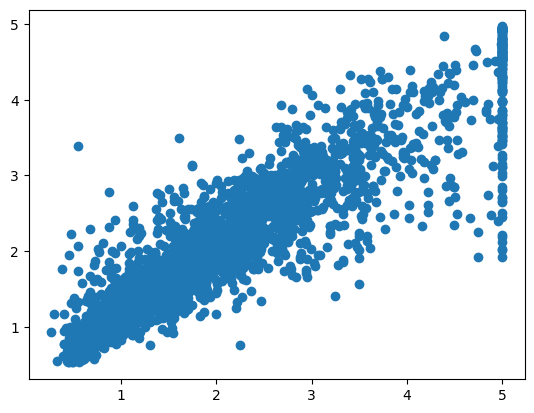

In [26]:
plt.scatter(y_val, y_pred_val_rf)

## Gradient Boosted Models

In [30]:
gbt_regressor = GradientBoostingRegressor(n_estimators=1000,
                                    max_depth=5,
                                    random_state=RANDOM_STATE)
gbt_regressor.fit(X_train, y_train)

,"loss loss: {'squared_error', 'absolute_error', 'huber', 'quantile'}, default='squared_error'Loss function to be optimized. 'squared_error' refers to the squarederror for regression. 'absolute_error' refers to the absolute error ofregression and is a robust loss function. 'huber' is acombination of the two. 'quantile' allows quantile regression (use`alpha` to specify the quantile).See:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_quantile.py`for an example that demonstrates quantile regression for creatingprediction intervals with `loss='quantile'`.",'squared_error'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",1000
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are""friedman_mse"" for the mean squared error with improvement score byFriedman, ""squared_error"" for mean squared error. The default value of""friedman_mse"" is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",5
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft

In [31]:
y_pred_val_gbt = gbt_regressor.predict(X_val)

print("\nEvaluating model performance:")
print(f"Train MSE:\t\t{mean_squared_error(y_train, gbt_regressor.predict(X_train)):.4f}")
print(f"Validation MSE:\t\t{mean_squared_error(y_val, gbt_regressor.predict(X_val)):.4f}")

print(f"\nTrain R2:\t\t{r2_score(y_train, gbt_regressor.predict(X_train)):.4f}")
print(f"Validation R2:\t\t{r2_score(y_val, gbt_regressor.predict(X_val)):.4f}")


Evaluating model performance:
Train MSE:		0.0288
Validation MSE:		0.2287

Train R2:		0.9784
Validation R2:		0.8338


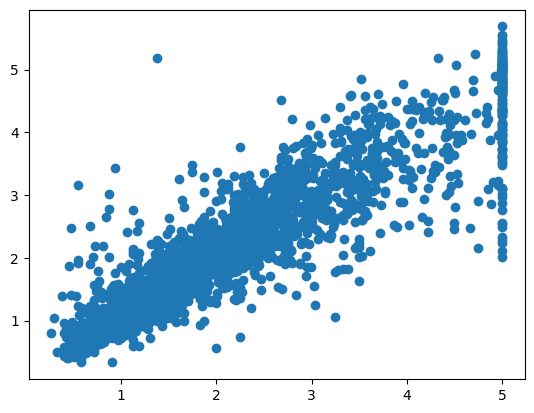

In [32]:
plt.scatter(y_val, y_pred_val_gbt)

In [35]:
from xgboost import XGBRegressor
xgb_regressor = XGBRegressor(n_estimators=10000,
                             eta=0.5,
                             max_depth=3,
                            random_state=RANDOM_STATE)


xgb_regressor.fit(X_train, y_train)

,"objective objective: str | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,None
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_met

In [36]:
y_pred_val_xgb = xgb_regressor.predict(X_val)

print("\nEvaluating model performance:")
print(f"Train MSE:\t\t{mean_squared_error(y_train, xgb_regressor.predict(X_train)):.4f}")
print(f"Validation MSE:\t\t{mean_squared_error(y_val, xgb_regressor.predict(X_val)):.4f}")

print(f"\nTrain R2:\t\t{r2_score(y_train, xgb_regressor.predict(X_train)):.4f}")
print(f"Validation R2:\t\t{r2_score(y_val, xgb_regressor.predict(X_val)):.4f}")


Evaluating model performance:
Train MSE:		0.0005
Validation MSE:		0.2745

Train R2:		0.9996
Validation R2:		0.8006


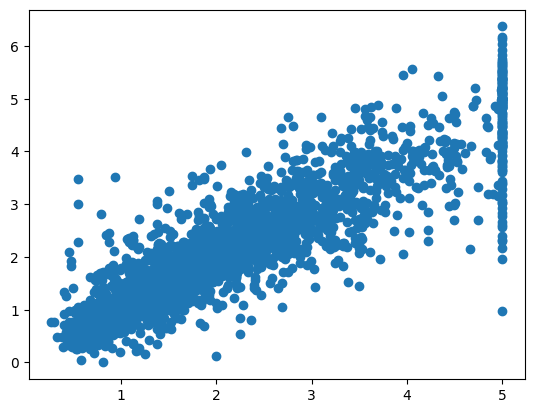

In [37]:
plt.scatter(y_val, y_pred_val_xgb)

## Model Selection & Evaluation

In [38]:
print(f"RF\tValidation R2:\t\t{r2_score(y_val, rf_regressor.predict(X_val)):.4f}")
print(f"GBT\tValidation R2:\t\t{r2_score(y_val, gbt_regressor.predict(X_val)):.4f}")
print(f"XGB\tValidation R2:\t\t{r2_score(y_val, xgb_regressor.predict(X_val)):.4f}")

RF	Validation R2:		0.8102
GBT	Validation R2:		0.8338
XGB	Validation R2:		0.8006


In [39]:
print(f"Test MSE: {mean_squared_error(y_test, xgb_regressor.predict(X_test))}")
print(f"Test R2: {r2_score(y_test, xgb_regressor.predict(X_test))}")

Test MSE: 0.24200190533960952
Test R2: 0.8156232301787087
